In [1]:
from google.colab import drive
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

In [2]:
drive.mount('/content/drive')
zip_path = "/content/drive/MyDrive/AI Club DC/AI Club DC Project/ASL_dynamic.zip"
!unzip -q "$zip_path" -d "/content/"

print("Contents of /content:")
print(os.listdir('/content'))

Mounted at /content/drive
Contents of /content:
['.config', 'ASL_dynamic', 'drive', 'sample_data']


In [3]:
DATASET_PATH = "/content/ASL_dynamic"
print("Dataset Structure")

Dataset Structure


In [ ]:
# Get class folders
class_folders = sorted([d for d in os.listdir(DATASET_PATH)
                       if os.path.isdir(os.path.join(DATASET_PATH, d))])

print(f"Classes found: {len(class_folders)}")
print(f"Class names: {class_folders}\n")

Classes found: 31
Class names: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'HELLO', 'I', 'J', 'K', 'L', 'M', 'N', 'NO', 'O', 'P', 'Q', 'R', 'S', 'SORRY', 'T', 'THANKYOU', 'U', 'V', 'W', 'X', 'Y', 'YES', 'Z']



In [ ]:
# Analyze first class
first_class = class_folders[0]
first_class_path = os.path.join(DATASET_PATH, first_class)
items = sorted(os.listdir(first_class_path))

In [ ]:
# Separate folders and videos
frame_folders = [i for i in items if os.path.isdir(os.path.join(first_class_path, i))]
videos = [i for i in items if i.endswith('.avi')]

print(f"Class '{first_class}':")
print(f"  Frame folders: {len(frame_folders)}")
print(f"  AVI files: {len(videos)}")

Class 'A':
  Frame folders: 10
  AVI files: 10


In [ ]:
# Check frames in first folder
if frame_folders:
    sample_folder = os.path.join(first_class_path, frame_folders[0])
    frames = sorted([f for f in os.listdir(sample_folder) if f.endswith('.jpg')])

    print(f"\nFolder: {frame_folders[0]}")
    print(f"  Frames: {len(frames)}")

    # Get frame size
    first_frame = os.path.join(sample_folder, frames[0])
    img = cv2.imread(first_frame)
    print(f"  Size: {img.shape[1]}x{img.shape[0]}")


Folder: A_clip10_frames
  Frames: 101
  Size: 640x480


In [ ]:
# Count per class
print("Samples per class:")
for cls in class_folders:
    cls_path = os.path.join(DATASET_PATH, cls)
    folders = [i for i in os.listdir(cls_path)
              if os.path.isdir(os.path.join(cls_path, i))]
    print(f"{cls}: {folders}")


Samples per class:
A: ['A_clip1_frames', 'A_clip7_frames', 'A_clip4_frames', 'A_clip8_frames', 'A_clip6_frames', 'A_clip5_frames', 'A_clip3_frames', 'A_clip9_frames', 'A_clip2_frames', 'A_clip10_frames']
B: ['B_clip5_frames', 'B_clip9_frames', 'B_clip3_frames', 'B_clip6_frames', 'B_clip8_frames', 'B_clip7_frames', 'B_clip10_frames', 'B_clip2_frames', 'B_clip1_frames', 'B_clip4_frames']
C: ['C_clip2_frames', 'C_clip10_frames', 'C_clip9_frames', 'C_clip8_frames', 'C_clip1_frames', 'C_clip4_frames', 'C_clip6_frames', 'C_clip5_frames', 'C_clip7_frames', 'C_clip3_frames']
D: ['D_clip4_frames', 'D_clip1_frames', 'D_clip7_frames', 'D_clip5_frames', 'D_clip2_frames', 'D_clip9_frames', 'D_clip3_frames', 'D_clip8_frames', 'D_clip10_frames', 'D_clip6_frames']
E: ['E_clip4_frames', 'E_clip1_frames', 'E_clip9_frames', 'E_clip2_frames', 'E_clip8_frames', 'E_clip5_frames', 'E_clip7_frames', 'E_clip10_frames', 'E_clip3_frames', 'E_clip6_frames']
F: ['F_clip2_frames', 'F_clip3_frames', 'F_clip10_frames

Visualizing 16-frame sequence.


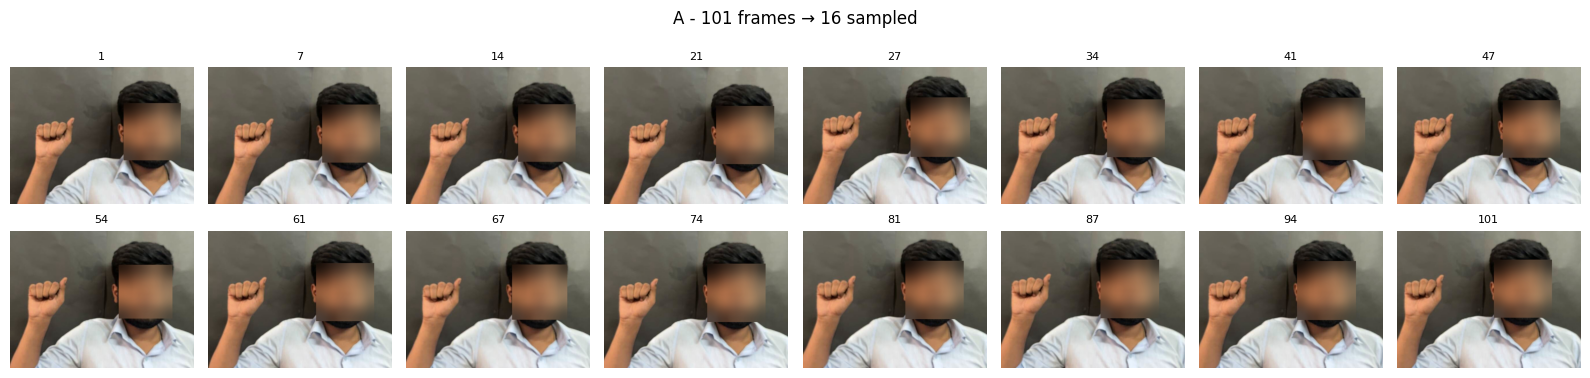

Saved: sequence.png


In [ ]:
# Visualize 16-frame sequence
print("Visualizing 16-frame sequence.")

indices = np.linspace(0, len(frames)-1, 16, dtype=int)

fig, axes = plt.subplots(2, 8, figsize=(16, 4))

for idx, ax in enumerate(axes.flat):
    frame_path = os.path.join(sample_folder, frames[indices[idx]])
    img = cv2.imread(frame_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    ax.imshow(img)
    ax.set_title(f"{indices[idx]+1}", fontsize=8)
    ax.axis('off')

plt.suptitle(f'{first_class} - {len(frames)} frames → 16 sampled', fontsize=12)
plt.tight_layout()
plt.savefig('sequence.png', dpi=150)
plt.show()
print("Saved: sequence.png")

EXPLORATION 1: Frame-to-Frame Differences

Analyzing: A/A_clip10_frames
Total frames: 101

Frame 0 → 1: Difference = 1.72
Frame 1 → 2: Difference = 1.76
Frame 2 → 3: Difference = 1.07
Frame 3 → 4: Difference = 3.25
Frame 4 → 5: Difference = 2.50
Frame 5 → 6: Difference = 4.61
Frame 6 → 7: Difference = 1.70
Frame 7 → 8: Difference = 1.37
Frame 8 → 9: Difference = 4.40
Frame 9 → 10: Difference = 5.25
Frame 10 → 11: Difference = 3.60
Frame 11 → 12: Difference = 2.08
Frame 12 → 13: Difference = 3.68
Frame 13 → 14: Difference = 3.10
Frame 14 → 15: Difference = 3.30
Frame 15 → 16: Difference = 2.44
Frame 16 → 17: Difference = 3.25
Frame 17 → 18: Difference = 2.14
Frame 18 → 19: Difference = 3.20

Average frame difference: 2.86
Max difference: 5.25
Min difference: 1.07

EXPLORATION 2: Compare Different Sequences of Same Class
A_clip10_frames: Shape (480, 640)
A_clip1_frames: Shape (480, 640)
A_clip2_frames: Shape (480, 640)

Pairwise differences between sequences:
Sequence 1 vs 2: 47.48
Seque

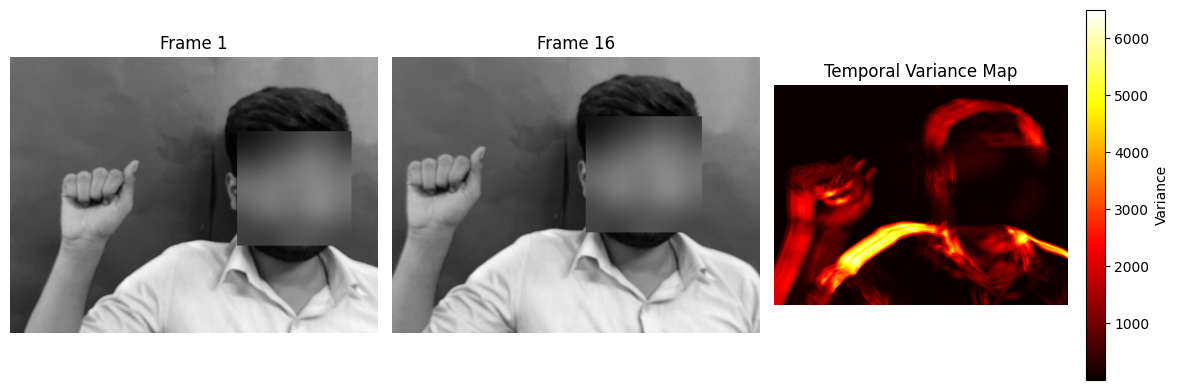


✓ Saved temporal_variance.png

EXPLORATION 4: Compare Static vs Dynamic Signs

Checking STATIC letters (should have low variance):
  A: Mean variance = 518.28
  B: Mean variance = 366.99
  C: Mean variance = 756.36

Checking DYNAMIC letters (should have higher variance):
  J: Mean variance = 479.23
  Z: Mean variance = 821.61

EXPLORATION 5: Visualize Motion (if any)


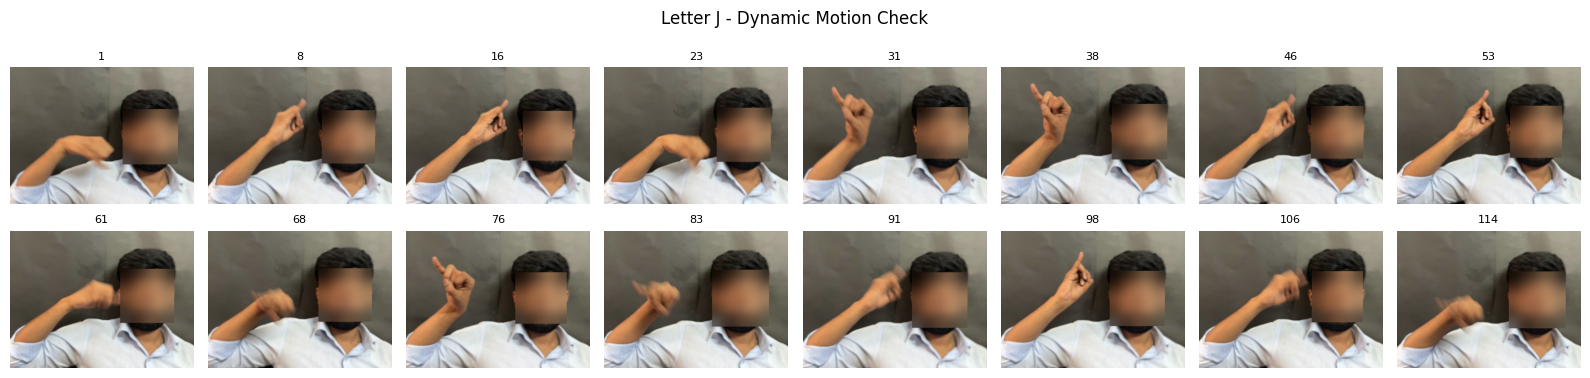

✓ Saved letter_j_motion.png

SUMMARY & RECOMMENDATIONS

Based on the analysis above:
1. Frame-to-frame differences tell us if there's motion
2. Temporal variance shows which pixels change over time
3. Comparing static vs dynamic letters reveals dataset characteristics

If variance is LOW (<5):
  → Dataset is mostly static poses
  → LSTM won't help much, but we can still build it

If variance is MEDIUM (5-20):
  → Some motion exists, LSTM should help

If variance is HIGH (>20):
  → Significant motion, LSTM is essential


In [4]:
# DEEP DATA EXPLORATION - Understanding Temporal Patterns

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

DATASET_PATH = "/content/ASL_dynamic"

print("="*60)
print("EXPLORATION 1: Frame-to-Frame Differences")
print("="*60)

# Pick one sequence and check how much frames differ
first_class = 'A'
cls_path = os.path.join(DATASET_PATH, first_class)
folders = sorted([f for f in os.listdir(cls_path) if os.path.isdir(os.path.join(cls_path, f))])
sample_folder = os.path.join(cls_path, folders[0])
frames = sorted([f for f in os.listdir(sample_folder) if f.endswith('.jpg')])

print(f"\nAnalyzing: {first_class}/{folders[0]}")
print(f"Total frames: {len(frames)}\n")

# Load all frames and compute differences
frame_diffs = []
prev_frame = None

for i in range(min(20, len(frames))):  # Check first 20 frames
    frame_path = os.path.join(sample_folder, frames[i])
    frame = cv2.imread(frame_path, cv2.IMREAD_GRAYSCALE)

    if prev_frame is not None:
        diff = np.abs(frame.astype(float) - prev_frame.astype(float)).mean()
        frame_diffs.append(diff)
        print(f"Frame {i-1} → {i}: Difference = {diff:.2f}")

    prev_frame = frame

print(f"\nAverage frame difference: {np.mean(frame_diffs):.2f}")
print(f"Max difference: {np.max(frame_diffs):.2f}")
print(f"Min difference: {np.min(frame_diffs):.2f}")

print("\n" + "="*60)
print("EXPLORATION 2: Compare Different Sequences of Same Class")
print("="*60)

# Compare 3 different sequences of letter A
if len(folders) >= 3:
    sequences_to_compare = folders[:3]

    # Get middle frame from each sequence
    middle_frames = []
    for folder in sequences_to_compare:
        folder_path = os.path.join(cls_path, folder)
        frames_in_folder = sorted([f for f in os.listdir(folder_path) if f.endswith('.jpg')])
        mid_idx = len(frames_in_folder) // 2
        mid_frame_path = os.path.join(folder_path, frames_in_folder[mid_idx])

        frame = cv2.imread(mid_frame_path, cv2.IMREAD_GRAYSCALE)
        middle_frames.append(frame)
        print(f"{folder}: Shape {frame.shape}")

    # Compare sequences pairwise
    print("\nPairwise differences between sequences:")
    for i in range(len(middle_frames)):
        for j in range(i+1, len(middle_frames)):
            diff = np.abs(middle_frames[i].astype(float) - middle_frames[j].astype(float)).mean()
            print(f"Sequence {i+1} vs {j+1}: {diff:.2f}")

print("\n" + "="*60)
print("EXPLORATION 3: Temporal Variation Within Sequence")
print("="*60)

# Sample 16 frames and check variation
indices = np.linspace(0, len(frames) - 1, 16, dtype=int)
sampled_frames = []

for i in indices:
    frame_path = os.path.join(sample_folder, frames[i])
    frame = cv2.imread(frame_path, cv2.IMREAD_GRAYSCALE)
    sampled_frames.append(frame)

# Compute variance across the 16 sampled frames
frames_array = np.array(sampled_frames)  # (16, H, W)
temporal_variance = np.var(frames_array, axis=0)  # Variance per pixel

print(f"Temporal variance stats:")
print(f"  Mean variance: {temporal_variance.mean():.2f}")
print(f"  Max variance: {temporal_variance.max():.2f}")
print(f"  Pixels with variance > 10: {(temporal_variance > 10).sum()}")
print(f"  Total pixels: {temporal_variance.size}")

# Visualize variance map
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(sampled_frames[0], cmap='gray')
plt.title('Frame 1')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(sampled_frames[-1], cmap='gray')
plt.title(f'Frame {len(indices)}')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(temporal_variance, cmap='hot')
plt.colorbar(label='Variance')
plt.title('Temporal Variance Map')
plt.axis('off')

plt.tight_layout()
plt.savefig('temporal_variance.png', dpi=150)
plt.show()
print("\n✓ Saved temporal_variance.png")

print("\n" + "="*60)
print("EXPLORATION 4: Compare Static vs Dynamic Signs")
print("="*60)

# Check letters that should be static (A, B) vs dynamic (J, Z)
static_letters = ['A', 'B', 'C']
dynamic_letters = ['J', 'Z']  # These require motion in real ASL

print("\nChecking STATIC letters (should have low variance):")
for letter in static_letters:
    if letter in os.listdir(DATASET_PATH):
        letter_path = os.path.join(DATASET_PATH, letter)
        folders = [f for f in os.listdir(letter_path) if os.path.isdir(os.path.join(letter_path, f))]
        if folders:
            folder_path = os.path.join(letter_path, folders[0])
            frames_list = sorted([f for f in os.listdir(folder_path) if f.endswith('.jpg')])

            # Sample 10 frames
            indices = np.linspace(0, len(frames_list) - 1, 10, dtype=int)
            frames_data = []
            for i in indices:
                frame = cv2.imread(os.path.join(folder_path, frames_list[i]), cv2.IMREAD_GRAYSCALE)
                frames_data.append(frame)

            variance = np.var(np.array(frames_data), axis=0).mean()
            print(f"  {letter}: Mean variance = {variance:.2f}")

print("\nChecking DYNAMIC letters (should have higher variance):")
for letter in dynamic_letters:
    if letter in os.listdir(DATASET_PATH):
        letter_path = os.path.join(DATASET_PATH, letter)
        folders = [f for f in os.listdir(letter_path) if os.path.isdir(os.path.join(letter_path, f))]
        if folders:
            folder_path = os.path.join(letter_path, folders[0])
            frames_list = sorted([f for f in os.listdir(folder_path) if f.endswith('.jpg')])

            indices = np.linspace(0, len(frames_list) - 1, 10, dtype=int)
            frames_data = []
            for i in indices:
                frame = cv2.imread(os.path.join(folder_path, frames_list[i]), cv2.IMREAD_GRAYSCALE)
                frames_data.append(frame)

            variance = np.var(np.array(frames_data), axis=0).mean()
            print(f"  {letter}: Mean variance = {variance:.2f}")

print("\n" + "="*60)
print("EXPLORATION 5: Visualize Motion (if any)")
print("="*60)

# Check J (should be dynamic - drawing J in air)
if 'J' in os.listdir(DATASET_PATH):
    j_path = os.path.join(DATASET_PATH, 'J')
    j_folders = [f for f in os.listdir(j_path) if os.path.isdir(os.path.join(j_path, f))]

    if j_folders:
        j_folder = os.path.join(j_path, j_folders[0])
        j_frames = sorted([f for f in os.listdir(j_folder) if f.endswith('.jpg')])

        # Sample 16 frames
        indices = np.linspace(0, len(j_frames) - 1, 16, dtype=int)

        fig, axes = plt.subplots(2, 8, figsize=(16, 4))
        for idx, ax in enumerate(axes.flat):
            frame_path = os.path.join(j_folder, j_frames[indices[idx]])
            img = cv2.imread(frame_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            ax.imshow(img)
            ax.set_title(f"{indices[idx]+1}", fontsize=8)
            ax.axis('off')

        plt.suptitle(f'Letter J - Dynamic Motion Check', fontsize=12)
        plt.tight_layout()
        plt.savefig('letter_j_motion.png', dpi=150)
        plt.show()
        print("✓ Saved letter_j_motion.png")

print("\n" + "="*60)
print("SUMMARY & RECOMMENDATIONS")
print("="*60)
print("\nBased on the analysis above:")
print("1. Frame-to-frame differences tell us if there's motion")
print("2. Temporal variance shows which pixels change over time")
print("3. Comparing static vs dynamic letters reveals dataset characteristics")
print("\nIf variance is LOW (<5):")
print("  → Dataset is mostly static poses")
print("  → LSTM won't help much, but we can still build it")
print("\nIf variance is MEDIUM (5-20):")
print("  → Some motion exists, LSTM should help")
print("\nIf variance is HIGH (>20):")
print("  → Significant motion, LSTM is essential")